Dans ce notebook, on va génére un "mock" catalogue à partir d'un certain range de masse et l'utilisation de la fonction de masse 2016 Bocquet et la relation de scaling Maughan 2013. On va faire "l'aller-retour" entre notre fonction de masse et notre catalogue afin de tester la relation d'échelle. Ensuite, on va faire la même chose en aplpliquant la coupure sur le count-rate pour se préparer à le faire sur le catalogue eRASS1 réel.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import importlib
from scipy.interpolate import UnivariateSpline
from scipy import integrate
from scipy.optimize import root_scalar

import halo_and_cluster_MF as hcmf
import useful_functions as uf

cosmo = Planck18


In [50]:
importlib.reload(hcmf) ; importlib.reload(uf)

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

# Définitions grandeurs utiles

In [84]:
# Caractéristiques de  notre mock catalogue
# Redshift
bornes_z = [0.05,1.5]
nb_bins_z = 50
range_z = np.linspace(bornes_z[0],bornes_z[1],nb_bins_z+1) # On définit le range de z étudié
mean_values_range_z = []
for i in range(nb_bins_z):
    mean_values_range_z.append((range_z[i]+range_z[i+1])/2)
mean_values_range_z = np.array(mean_values_range_z)
bin_width_z = range_z[1]-range_z[0]

# Masse
bornes_log_10_M = [12.5, 15.5]
nb_bins_M = 1000
range_log10_M_Msun = np.linspace(bornes_log_10_M[0],bornes_log_10_M[1],nb_bins_M+1) # On définit le range de masse étudié
mean_values_range_log10_M_Msun = []
for i in range(nb_bins_M):
    mean_values_range_log10_M_Msun.append((range_log10_M_Msun[i]+range_log10_M_Msun[i+1])/2)
mean_values_range_log10_M_Msun = np.array(mean_values_range_log10_M_Msun)
bin_width_log10_M_Msun = range_log10_M_Msun[1]-range_log10_M_Msun[0]  

# Surface angulaire et volume
angular_area_deg2 = 10000 # Surface angulaire couverte
volume_survey = uf.Volume_survey(angular_area_deg2,bornes_z) # Volume de la région observée

In [52]:
np.shape(range_z)

(51,)

In [53]:
bin_width_log10_M_Msun

np.float64(0.0030000000000001137)

# Création du mock catalogue à partir de la fonction de masse

## Calcul des valeurs M500 et z du mock catalogue

In [54]:
# J'utilise la fonction de masse Bocquet_2016 pour calculer (dn/dlog10(M500))(M500,z)

CMF_table_values = []
for z in mean_values_range_z:
    CMF_table_values.append(hcmf.CMF_Bocquet_2016_log10(10**mean_values_range_log10_M_Msun,z))

# Le ième élément de CMF table values représente les valeurs de la fonctions de masse pour le ième redshift de mean_values_range_z

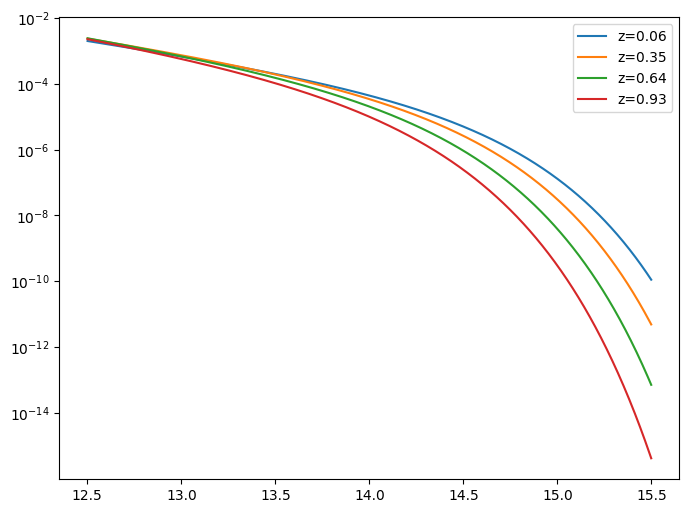

In [55]:
plt.figure(figsize=(8,6))
for i in range(4):
    plt.plot(mean_values_range_log10_M_Msun,CMF_table_values[10*i],label=f'z={mean_values_range_z[10*i]:.2f}')
plt.legend()
plt.yscale('log')

In [56]:
# On va calculer pour chaque bin de masse et chaque bin de redshift (on fait correspondre au bin de z_j le volume de la coquille sphérique d'épaisseur (D_comobile(z_j+1)-D_comobile(z_j)) ) son nombre de clusters associés

Proxy_N_table_values = np.zeros([nb_bins_z,nb_bins_M]) # N désigne un nombre de clusters : on parle de ici de "Proxy_N" car c'est la quantité qu'on va arrondir pour obtenir N

for i in range(nb_bins_z): # Pour chaque bin de redshift
    CMF_current_bin_z = CMF_table_values[i]
    for j in range(nb_bins_M): # Pour chaque bin de masse
        Proxy_N_table_values[i,j] = CMF_current_bin_z[j]*bin_width_log10_M_Msun*uf.Volume_survey(angular_area_deg2,[range_z[i],range_z[i+1]])

In [ ]:
N_table_values = np.rint(Proxy_N_table_values).astype(int) # On approxime à un nombre entier chaque float de Proxy_N_table_values
N_total_clusters = N_table_values.sum()
print("Approximation du nombre total de clusters : ",N_total_clusters)

Approximation du nombre total de clusters :  65013348


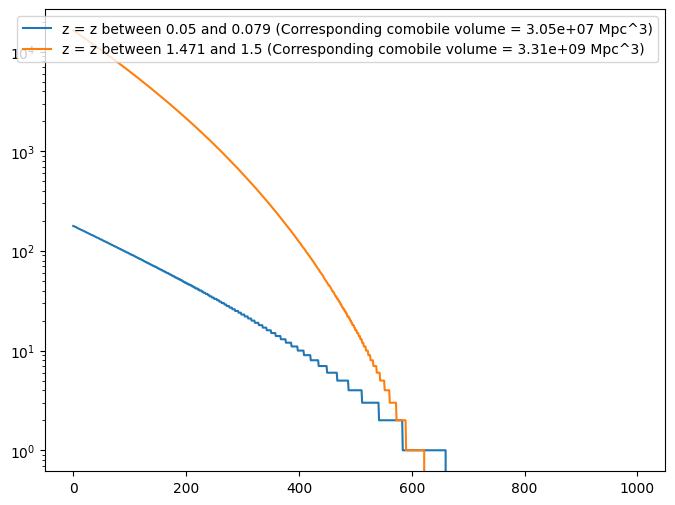

In [58]:
plt.figure(figsize=(8,6))
plt.plot(N_table_values[0],label=f'z = z between {range_z[0]} and {range_z[1]} (Corresponding comobile volume = {uf.Volume_survey(angular_area_deg2,[range_z[0],range_z[1]]):.2e} Mpc^3)')
plt.plot(N_table_values[49],label=f'z = z between {np.round(range_z[49],3)} and {range_z[50]} (Corresponding comobile volume = {uf.Volume_survey(angular_area_deg2,[range_z[49],range_z[50]]):.2e} Mpc^3)')
plt.yscale('log')
plt.legend()

## On récupère les valeurs pour créer le catalogue

In [ ]:
# Creation of the mock_catalogue DataFrame

# Use the meshgrid and flattening as defined in cell 15
zz, mm = np.meshgrid(mean_values_range_z, mean_values_range_log10_M_Msun, indexing='ij')
flat_z = zz.flatten()
flat_m = mm.flatten()
flat_n = N_table_values.flatten()

mock_masses = np.repeat(flat_m, flat_n)
mock_redshifts = np.repeat(flat_z, flat_n)

mock_catalogue = pd.DataFrame({
    'log10_M500': mock_masses,
    'z': mock_redshifts
})

print(mock_catalogue)
print(f"Total clusters in mock catalogue: {len(mock_catalogue)}")


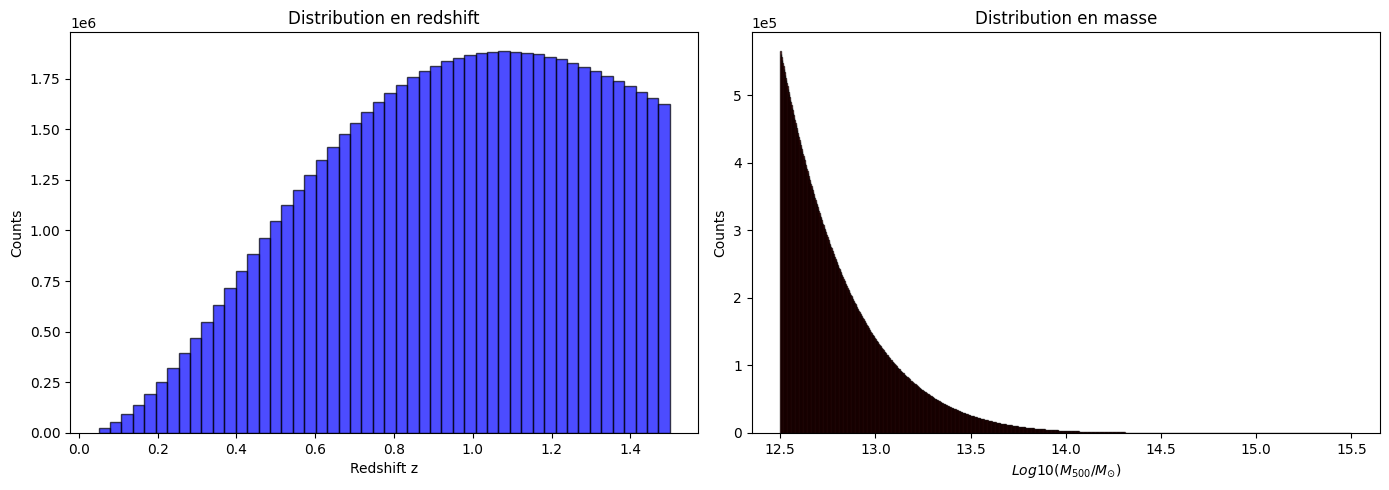

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Redshift histogram
axs[0].hist(mock_catalogue['z'], bins=range_z, alpha=0.7, color='blue', edgecolor='black')
axs[0].set_xlabel('Redshift z')
axs[0].set_title('Distribution en redshift')

# Mass histogram
counts, bins, patches = axs[1].hist(mock_catalogue['log10_M500'], bins=range_log10_M_Msun, alpha=0.7, color='red', edgecolor='black')
axs[1].set_xlabel(r'$Log10(M_{500}$/$M_{\odot}$)')
axs[1].set_title(r'Distribution en masse')
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.show()

## Calculs de Lx et CR :

In [69]:
# Utilisation de la relation d'échelle pour Maughan et al. 2013 pour calculer la colonne Lx :
mock_Lx = uf.Lx_from_M_Maughan(10**mock_masses, mock_redshifts)
mock_catalogue['Lx'] = mock_Lx

In [72]:
importlib.reload(uf)

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

In [ ]:
# Utilisation de la relation CR-Lx
mock_CR = uf.CR_from_LX_faster(mock_Lx,mock_redshifts)
mock_catalogue['CR'] = mock_CR   

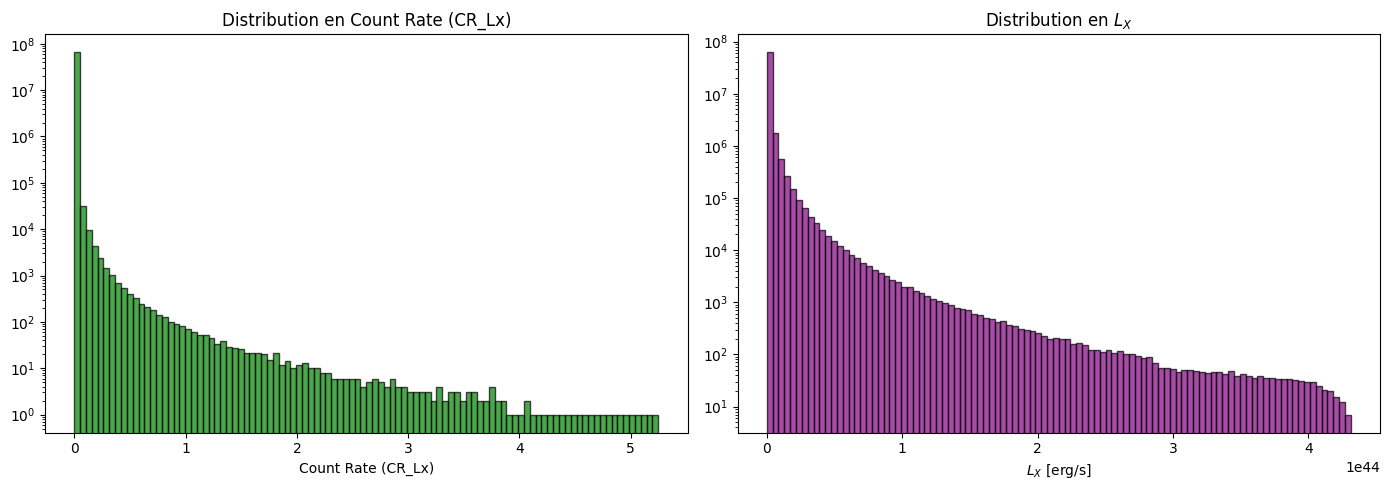

In [79]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# CR_Lx histogram
axs[0].hist(mock_catalogue['CR_Lx'], bins=100, alpha=0.7, color='green', edgecolor='black')
axs[0].set_xlabel('Count Rate (CR_Lx)')
axs[0].set_title('Distribution en Count Rate (CR_Lx)')
axs[0].set_yscale('log')

# Lx histogram
axs[1].hist(mock_catalogue['Lx'], bins=100, alpha=0.7, color='purple', edgecolor='black')
axs[1].set_xlabel(r'$L_X$ [erg/s]')
axs[1].set_title(r'Distribution en $L_X$')
axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [80]:
mock_catalogue

,log10_M500,z,Lx,CR_Lx
0,12.5015,0.0645,3.375826e+40,0.002970
1,12.5015,0.0645,3.375826e+40,0.002970
2,12.5015,0.0645,3.375826e+40,0.002970
3,12.5015,0.0645,3.375826e+40,0.002970
4,12.5015,0.0645,3.375826e+40,0.002970
...,...,...,...,...
65013343,14.3555,1.4855,3.773419e+44,0.024357
65013344,14.3585,1.4855,3.816410e+44,0.024634
65013345,14.3615,1.4855,3.859891e+44,0.024915
65013346,14.3645,1.4855,3.903867e+44,0.025199


# Chemin inverse : Mock catalogue → Fonction de masse

In [ ]:
# Data mock catalogue
bin_centers_log10_M, counts_log10_M, bin_width_log10_M, n_log10_M = uf.compute_histogram_density(
    data=mock_masses,
    bins=nb_bins_M,
    volume=volume_survey,
)

print("Bin width log_10_M500:", bin_width_log10_M)

Bin width log_10_M500: 0.002297999999999689


In [146]:
# Application de la CMF Bocquet 2016

z_mean_mock_catalogue = np.mean(mock_redshifts)
CMF_values_reconstructed = hcmf.CMF_Bocquet_2016_log10(10**bin_centers_log10_M, z_mean_mock_catalogue)

z_2 = 0.5
CMF_values_reconstructed_z2 = hcmf.CMF_Bocquet_2016_log10(10**bin_centers_log10_M, z_2)


In [104]:
z_mean_mock_catalogue

np.float64(0.9533090094667727)

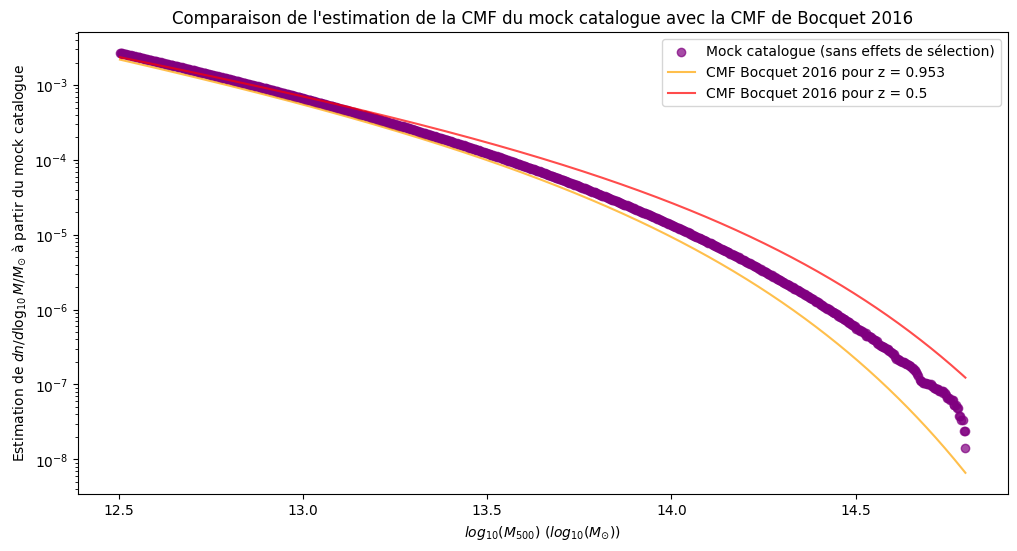

In [148]:
fig = plt.figure(figsize=(12, 6))

plt.scatter(bin_centers_log10_M, n_log10_M, color='purple', label='Mock catalogue (sans effets de sélection)', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $dn / d\log_{10} M / M_{\odot}$ à partir du mock catalogue')
plt.yscale('log')

plt.plot(bin_centers_log10_M, CMF_values_reconstructed, color='orange', label=f'CMF Bocquet 2016 pour z = {np.round(z_mean_mock_catalogue, 3)}', alpha=0.7)

plt.plot(bin_centers_log10_M, CMF_values_reconstructed_z2, color='red', label=f'CMF Bocquet 2016 pour z = {np.round(z_2, 3)}', alpha=0.7)

plt.yscale('log')

plt.title('Comparaison de l\'estimation de la CMF du mock catalogue avec la CMF de Bocquet 2016')
plt.legend()


plt.show()

# Création d'un mock catalogue avec effet de sélection en CR en fonction du mock catalogue de base

In [130]:
importlib.reload(uf)

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

In [131]:
# Caractéristiques de la coupure et de notre instrument

CR_min = 1e-3 # On ne détecte pas les sources avec un CR inférieur à 1e-3 (Insiré du catalogue eRASS1)

S_det = 2451 * 1e-4 # m^2 : Même surface de détection que eROSITA car c'est ce que j'ai utilisé pour calculer la colonne CR dans le mock catalogue
E_peak_kev = 2.821 * 0.5740 ; E_peak = E_peak_kev * 1.6022e-9  # erg : Valeur "pas simple" pour la même raison

In [132]:
# Calcul de la coupure en z pour chaque bin de Lx

# Définition de la fonction de distance lumineuse inverse :
#inverse_DL = uf.inverse_luminosity_distance([0.01,10,100000]) # Fonction inverse de la distance lumineuse ; !!! Attention le choix du range de z est important ! → le faire assez large
inverse_DL = uf.inverse_luminosity_distance_m([0.01,10,100000])


# Calcul de l'argument de inverse_DL
arg_inverse_DL = np.sqrt((1/CR_min)*(mock_Lx/E_peak)*(S_det/(4*np.pi)))

# Calcul de la coupure en z pour chaque cluster (plus précisément pour chaque lx associé à chaque cluster)
cut_z = inverse_DL(arg_inverse_DL)


In [133]:
arg_inverse_DL

array([1.59309208e+25, 1.59309208e+25, 1.59309208e+25, ...,
       1.70348526e+27, 1.71316179e+27, 1.72289329e+27], shape=(65013348,))

In [134]:
np.isnan(cut_z).sum()

np.int64(0)

In [135]:
cut_z

array([0.10793818, 0.10793818, 0.10793818, ..., 5.66871876, 5.69636303,
       5.72414852], shape=(65013348,))

In [136]:
# Maintenant qu'on dispose de la coupure en z pour chaque valeur de Lx, on peut maintenant filtrer la table
mock_catalogue_with_cut_z = mock_catalogue[mock_catalogue['z'] < cut_z]

In [137]:
mock_catalogue_with_cut_z

,log10_M500,z,Lx,CR_Lx
0,12.5015,0.0645,3.375826e+40,0.002970
1,12.5015,0.0645,3.375826e+40,0.002970
2,12.5015,0.0645,3.375826e+40,0.002970
3,12.5015,0.0645,3.375826e+40,0.002970
4,12.5015,0.0645,3.375826e+40,0.002970
...,...,...,...,...
65013343,14.3555,1.4855,3.773419e+44,0.024357
65013344,14.3585,1.4855,3.816410e+44,0.024634
65013345,14.3615,1.4855,3.859891e+44,0.024915
65013346,14.3645,1.4855,3.903867e+44,0.025199


In [140]:
prop_conserved_elements = len(mock_catalogue_with_cut_z) / len(mock_catalogue)
print(f"Proportion d'éléments conservés avec la coupure en z : {prop_conserved_elements:.2%}")

Proportion d'éléments conservés avec la coupure en z : 6.28%


## Caractéristiques du mock catalogue avec effet de sélection

In [141]:
# Data mock catalogue filtré
bin_centers_log10_M_cut_z, counts_log10_M_cut_z, bin_width_log10_M_cut_z, n_log10_M_cut_z = uf.compute_histogram_density(
    data=mock_catalogue_with_cut_z['log10_M500'],
    bins=nb_bins_M,
    range = [range_log10_M_Msun[0], range_log10_M_Msun[-1]],
    volume=volume_survey,
)

print("Bin width log_10_M500_cut_z:", bin_width_log10_M)

Bin width log_10_M500_cut_z: 0.002297999999999689


In [ ]:
'''# Application de la CMF Bocquet 2016

z_mean_mock_catalogue = np.mean(mock_redshifts)
CMF_values_reconstructed = hcmf.CMF_Bocquet_2016_log10(10**bin_centers_log10_M_cut_z, z_mean_mock_catalogue)

z_2 = 0.5
CMF_values_reconstructed_z2 = hcmf.CMF_Bocquet_2016_log10(10**bin_centers_log10_M_cut_z, z_2)
'''

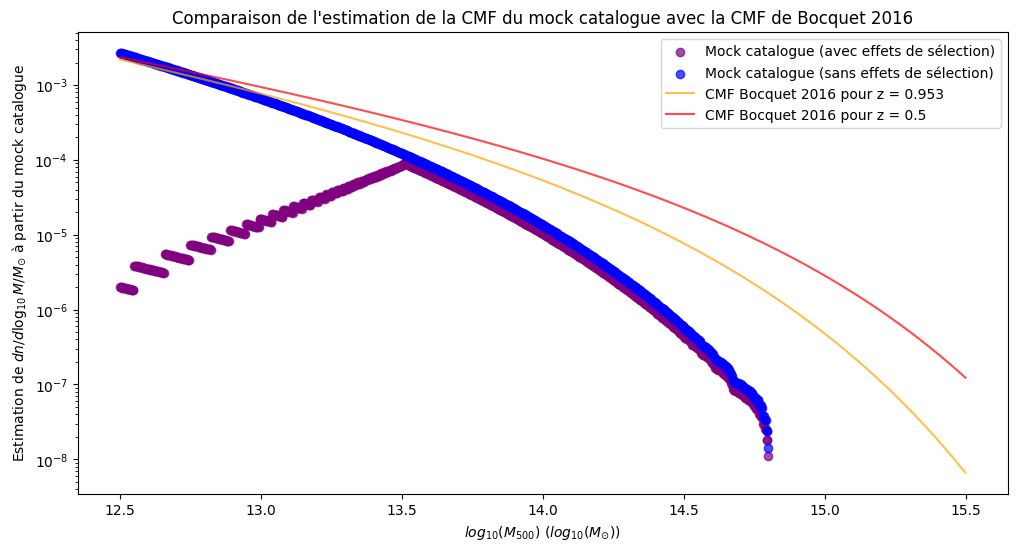

In [ ]:
fig = plt.figure(figsize=(12, 6))

plt.scatter(bin_centers_log10_M_cut_z, n_log10_M_cut_z, color='purple', label='Mock catalogue (avec effets de sélection)', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $dn / d\log_{10} M / M_{\odot}$ à partir du mock catalogue avec effet de sélection')
plt.yscale('log')

plt.scatter(bin_centers_log10_M, n_log10_M, color='blue', label='Mock catalogue (sans effets de sélection)', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $dn / d\log_{10} M / M_{\odot}$ à partir du mock catalogue')
plt.yscale('log')

plt.plot(bin_centers_log10_M_cut_z, CMF_values_reconstructed, color='orange', label=f'CMF Bocquet 2016 pour z = {np.round(z_mean_mock_catalogue, 3)}', alpha=0.7)

plt.plot(bin_centers_log10_M_cut_z, CMF_values_reconstructed_z2, color='red', label=f'CMF Bocquet 2016 pour z = {np.round(z_2, 3)}', alpha=0.7)

plt.yscale('log')

plt.title('Comparaison de l\'estimation de la CMF du mock catalogue avec la CMF de Bocquet 2016')
plt.legend()


plt.show()

# Pourquoi est ce le que le graphe est différent que dans le cas non filtré !!!